# Notebook 03 — descriptive segmentation (feature views)

**What is being segmented.** The pre-registration (`reports/pre_registration.md`
§2) approves three session segments for confirmatory comparison — **price tier**
(`budget`/`mid`/`premium`/`luxury` on merchandising bands), **visit kind**
(`new` vs `returning` by `session_number`), and **weekend vs weekday**
(`dayofweek` in {5, 6}). This notebook is the **descriptive** view of those
segments — the *feature views* the pre-registration names in §1: the overall
funnel is descriptive, and confirmatory comparisons begin only with its §3 list.

> **No inference here.** Everything in this notebook is descriptive: we state
> observed rates, sizes and shapes, with 95% Wilson CIs as sampling-uncertainty
> of the observed point estimates only. There are **no p-values, no tests, no
> significance claims**. The confirmed tests are the pre-registered comparisons
> — families A, B, C with their α, multiplicity corrections, sparse rule and
> practical-significance gate — run **exclusively in notebook 04**. The
> patterns at the end of this notebook are **candidate hypotheses to be tested
> there**; nothing is claimed as established here.


In [1]:
import os
import sys
from pathlib import Path


def _find_repo_root() -> Path:
    """Resolve the repo root from the kernel's CWD (cwd-independent cell).

    The build runner launches the kernel from the repo root, but a reader who
    re-executes the .ipynb from another directory must resolve the same data.
    Walk up until a directory contains both src/ and the sessions artifact; the
    is_file() guard below fails loudly instead of silently loading wrong data.
    """
    probe = Path(os.getcwd()).resolve()
    for _ in range(8):
        if (probe / "src").is_dir() and (
            probe / "data" / "processed" / "sessions.parquet"
        ).is_file():
            return probe
        parent = probe.parent
        if parent == probe:
            break
        probe = parent
    raise RuntimeError(
        "repo root not found from CWD="
        + str(Path(os.getcwd()))
        + "; expected a dir with src/ and data/processed/sessions.parquet"
    )


REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

SESSIONS_FILE = REPO_ROOT / "data" / "processed" / "sessions.parquet"

# Fail loudly if the processed artifact is missing — an empty segments table
# would otherwise sail through and silently change every downstream number.
if not SESSIONS_FILE.is_file():
    raise FileNotFoundError(f"missing processed artifact: {SESSIONS_FILE}")

# Analysis lives in src only — the notebook renders, it does not re-implement
# segment maths. src.plots import applies the shared matplotlib style, and the
# Agg backend set there is exactly what the headless saves of the four charts
# need.
import polars as pl  # noqa: E402
from IPython.display import Image, Markdown, display  # noqa: E402
from src.segments import assign_segments, segment_funnel  # noqa: E402
import src.plots  # noqa: E402,F401  (applies project style, sets Agg backend)
from src.plots import (  # noqa: E402
    assets_path,
    plot_price_conversion_curve,
    plot_segment_rates,
)

print(f"repo root:    {REPO_ROOT}")
print(f"sessions:     {SESSIONS_FILE}")


repo root:    /mnt/d/opencode/new20
sessions:     /mnt/d/opencode/new20/data/processed/sessions.parquet


In [2]:
# One row per user_session, the frozen unit of the whole project. assign_segments
# is the single owner of the five label columns — the notebook never derives a
# segment label itself, so src and notebook cannot drift.
sessions = pl.read_parquet(SESSIONS_FILE)
seg = assign_segments(sessions)
del sessions  # keep only the labelled frame; the raw frame is not needed again

print(f"loaded {seg.height:,} session rows")


loaded 4,535,941 session rows


In [3]:
# Segment sizes come from the segment_funnel frames themselves (n_sessions is
# the contract column for segment size) so this table is byte-consistent with
# data/processed/segment_<by>.csv written by scripts/explore_segments.py. The
# three frames are reused by the charts below — sizes and plotted rates come
# from the same objects by construction.
seg_price = segment_funnel(seg, "price_tier")
seg_visit = segment_funnel(seg, "visit_kind")
seg_weekend = segment_funnel(seg, "is_weekend")

# The "NA" price tier is counted from median_price nulls, not from the funnel
# frame: assign_segments labels a null price "NA", and with zero nulls in this
# dataset the segment produces no rows, so it must be reported explicitly rather
# than silently absent from the funnel output.
n_na_tier = int(seg["median_price"].null_count())


def _size_section(funnel: pl.DataFrame, subheader: str) -> str:
    """Render one family's (segment, n_sessions) pairs as a markdown block."""
    rows = funnel.select("segment", "n_sessions").unique().sort("segment")
    lines = [f"**{subheader}**", "", "| segment | n_sessions |", "|---|---:|"]
    total = 0
    for r in rows.iter_rows(named=True):
        lines.append(f"| {r['segment']} | {r['n_sessions']:,} |")
        total += r["n_sessions"]
    lines.append(f"| **total** | **{total:,}** |")
    return "\n".join(lines)


_lines = [
    _size_section(seg_price, "price_tier"),
    f"| NA (null median_price) | **{n_na_tier:,}** |",
    "",
    _size_section(seg_visit, "visit_kind"),
    "",
    # is_weekend labels are the frame's boolean-to-string "false"/"true"; the
    # legend maps them so the business reading is unambiguous without renaming
    # the frame's own values.
    _size_section(seg_weekend, "is_weekend  (false = weekday, true = weekend)"),
]
display(Markdown("\n".join(_lines)))


**price_tier**

| segment | n_sessions |
|---|---:|
| budget | 2,148,161 |
| luxury | 42,438 |
| mid | 1,942,774 |
| premium | 402,568 |
| **total** | **4,535,941** |
| NA (null median_price) | **0** |

**visit_kind**

| segment | n_sessions |
|---|---:|
| new | 1,638,963 |
| returning | 2,896,978 |
| **total** | **4,535,941** |

**is_weekend  (false = weekday, true = weekend)**

| segment | n_sessions |
|---|---:|
| false | 3,353,514 |
| true | 1,182,427 |
| **total** | **4,535,941** |

**Reading the sizes table.** Each family's sizes sum to all 4,535,941 sessions —
the segments partition the session table, they do not overlap.

- **price tier:** budget (≈47.4 %) and mid (≈42.8 %) together are 90 % of all
  sessions; premium is ≈8.9 %; **luxury is 42,438 sessions = 0.94 %**. The
  **"NA" tier (null `median_price`) holds 0 sessions** in this dataset — no
  session lacks a price, so the tier simply does not appear; it is reported
  explicitly rather than silently dropped. Luxury is already earmarked by the
  pre-registration's practical-significance rule (§5): at 0.94 % it is *below*
  the 1 % affected-volume threshold, so **by design** it is too small to be
  decision-relevant in any comparison it participates in. The narrative below
  respects that — a 42 k-session segment cannot carry a business verdict alone.
- **visit kind:** returning (≈63.9 %) outnumber new (≈36.1 %) by ~1.8× — a
  volume gap that matters for family B's capability, not for its direction.
- **weekend:** weekday (≈73.9 %) vs weekend (≈26.1 %).

These are feature views: they describe what the segments look like *before* any
comparison is tested (notebook 04).


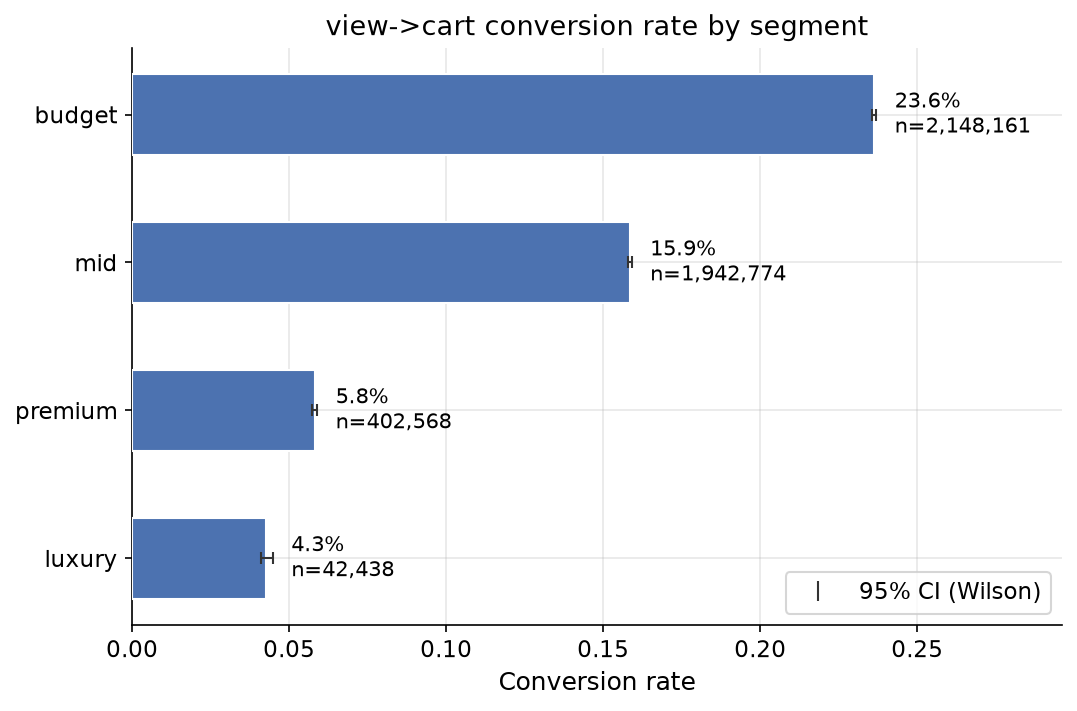

saved /mnt/d/opencode/new20/assets/seg_price_tier_view_cart.png


In [4]:
_tier_out = REPO_ROOT / assets_path("seg_price_tier_view_cart")
plot_segment_rates(seg_price, "view->cart", _tier_out)
display(Image(filename=str(_tier_out)))
print(f"saved {_tier_out}")


**Descriptive direction — price tier vs view→cart.** The gradient runs
monotone-decreasing across tiers: budget 23.6 % → mid 15.9 % → premium 5.8 % →
luxury 4.3 %. The cheapest tier converts at roughly **5.5×** the luxury rate
(23.6 % vs 4.3 %) on this sample — precisely the signal family A was designed
around. But this is **numbers only**: no test yet, and per the note above the
luxury leg must not be dressed up as an actionable finding (0.94 % of sessions).
Notebook 04 tests the pre-registered 4×2 χ² and the six pairwise z-tests.


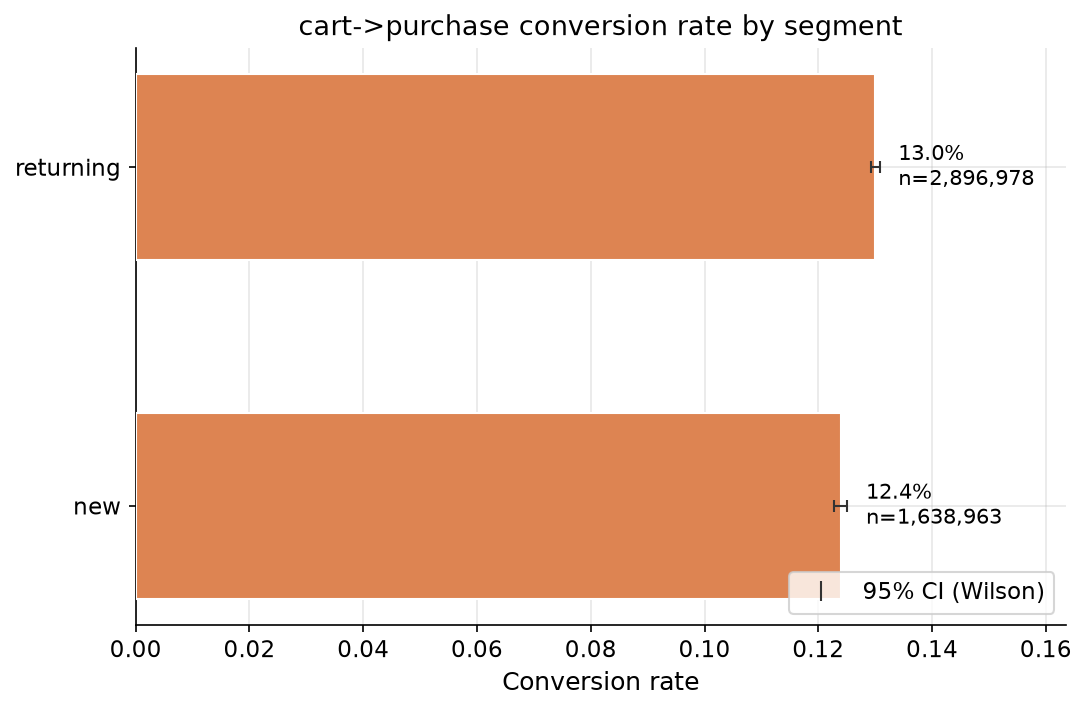

saved /mnt/d/opencode/new20/assets/seg_visit_cart_purchase.png


In [5]:
_visit_out = REPO_ROOT / assets_path("seg_visit_cart_purchase")
plot_segment_rates(seg_visit, "cart->purchase", _visit_out)
display(Image(filename=str(_visit_out)))
print(f"saved {_visit_out}")


**Descriptive direction — visit kind vs cart→purchase.** Returning sessions
convert slightly above new ones (13.0 % vs 12.4 %, ≈0.6 pp) — a mild positive
reading for returning visitors on this sample. Descriptive only; whether the
difference is distinguishable from noise is family B's single pre-registered
z-test in notebook 04.


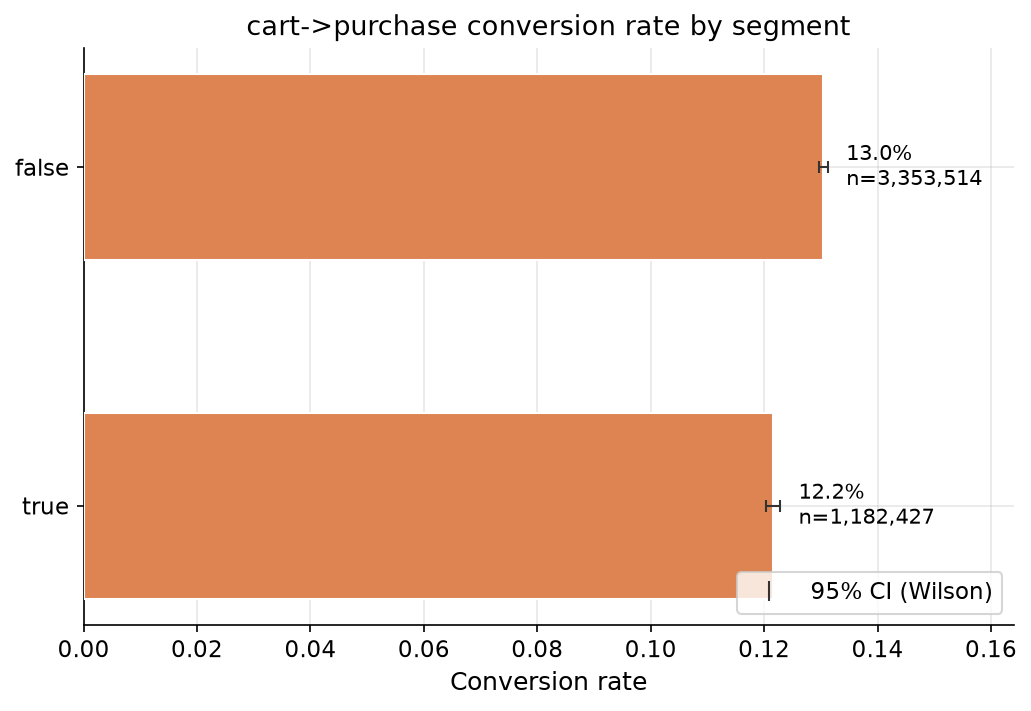

saved /mnt/d/opencode/new20/assets/seg_weekend_cart_purchase.png


In [6]:
_weekend_out = REPO_ROOT / assets_path("seg_weekend_cart_purchase")
plot_segment_rates(seg_weekend, "cart->purchase", _weekend_out)
display(Image(filename=str(_weekend_out)))
print(f"saved {_weekend_out}")


**Descriptive direction — weekend vs cart→purchase.** Weekday sessions convert
slightly above weekend ones (13.0 % vs 12.2 %, ≈0.9 pp) — a mild *negative*
"weekend effect" on this sample. Descriptive only; family C's single z-test in
notebook 04 decides whether it is distinguishable from noise.


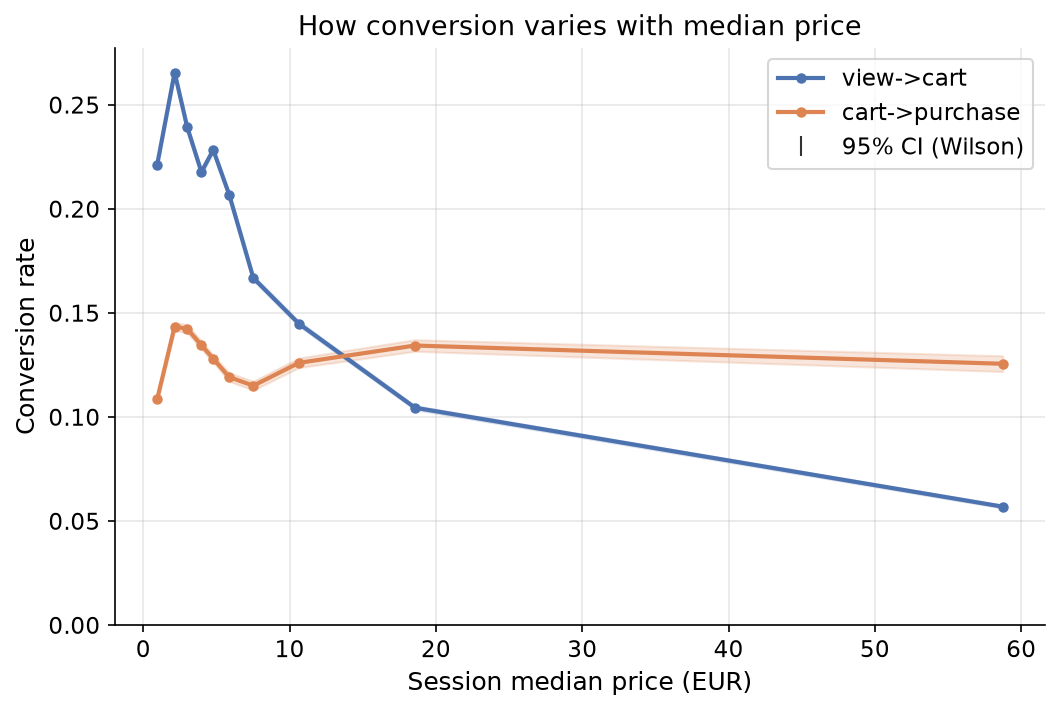

saved /mnt/d/opencode/new20/assets/price_conversion_curve.png


In [7]:
_curve_out = REPO_ROOT / assets_path("price_conversion_curve")
plot_price_conversion_curve(seg, _curve_out)
display(Image(filename=str(_curve_out)))
print(f"saved {_curve_out}")


**Reading the price curve.** Sessions are binned by median price into deciles
(x = median price of each bin, EUR); both step rates carry Wilson ribbons.

- **view→cart** is broadly **price-decreasing, but not monotonic at the low
  end**: the rate is ≈22 % in the cheapest decile, peaks near ≈26 % around the
  ~2 EUR bin, then falls steadily to ≈5.7 % in the top decile (≈59 EUR) — a
  roughly 4–5× span from the low-price peak to the top decile. The dip of the
  very cheapest bin below the second is visible but not interpreted.
- **cart→purchase** is **approximately flat** across the whole price range: it
  wanders within ≈11–14 % with no systematic increasing or decreasing trend.

No significance claims: these are the observed shapes of this dataset. Whether
any slope is distinguishable from flat is not tested here.


## Candidate hypotheses for notebook 04 (to be tested, not concluded here)

Patterns observed above, listed as hypotheses to be **tested** against the
pre-registered rules — nothing in this list is claimed as established.

**Family A — price tier × view→cart**
- H (descriptive signal): view→cart decreases with price tier (budget 23.6 % >
  mid 15.9 % > premium 5.8 % > luxury 4.3 %), notably a ~5.5× budget-vs-luxury
  gap. Notebook 04: 4×2 χ² + 6 pairwise z-tests (Bonferroni α* = 0.0083, FDR as
  sensitivity, sparse rule, NA tier excluded with an explicit note).

**Family B — visit kind × cart→purchase**
- H (descriptive signal): returning converts slightly above new (13.0 % vs
  12.4 %, ≈0.6 pp). Notebook 04: single two-proportion z-test, new vs returning,
  on cart sessions.

**Family C — weekend × cart→purchase**
- H (descriptive signal): weekday converts slightly above weekend (13.0 % vs
  12.2 %, ≈0.9 pp). Notebook 04: single two-proportion z-test, weekend vs
  weekday, on cart sessions.

The pre-registered decision rule (§4–§5) decides what, if anything, passes:
α = 0.05 two-sided, per-family Bonferroni, and — separately from any p-value —
the practical gate (CI excludes 0 AND |relative uplift| ≥ 10 % AND affected
volume ≥ 1 %, i.e. ≥ 45,360 sessions, with luxury below the bar by design).
